<a href="https://colab.research.google.com/github/M4rck0/Procesamiento_Clasificacion_Datos/blob/main/Tarea_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Librerías
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
imagen = cv2.imread('imagen_actividad.png')

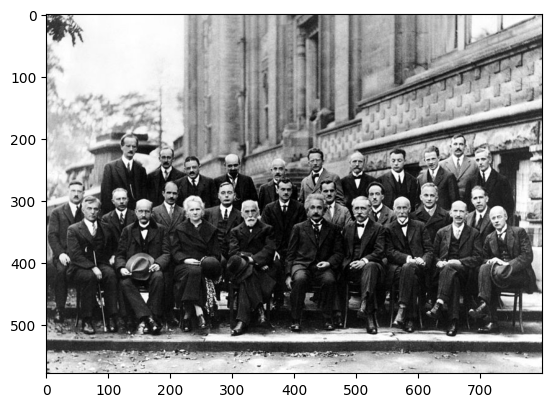

In [6]:
# Convertir a RGB
img_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

plt.figure()
plt.imshow(img_rgb)
plt.show()

In [7]:
# Tamaño
print("Dimensiones de la imagen:")
print(imagen.shape)

alto, ancho = imagen.shape[:2]
print(f"Alto: {alto} pixeles")
print(f"Ancho: {ancho} pixeles")

Dimensiones de la imagen:
(579, 800, 3)
Alto: 579 pixeles
Ancho: 800 pixeles


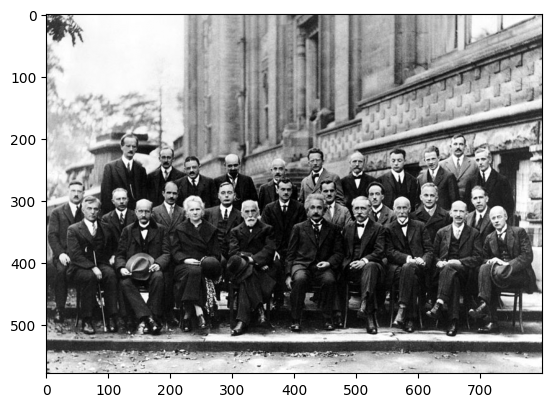

In [9]:
# Escala de grises
grises = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

plt.figure()
plt.imshow(grises, cmap="gray")
plt.show()

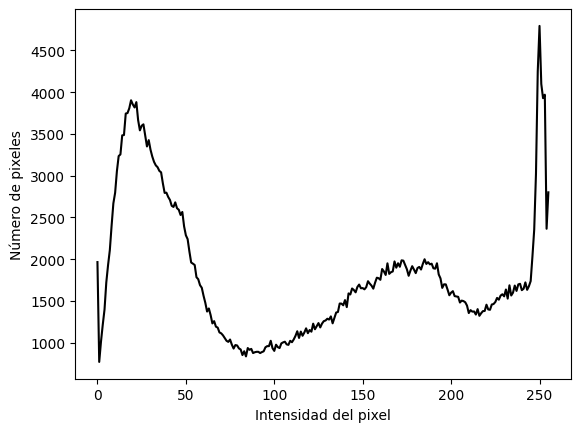

In [11]:
# Histograma de grises
hist_grises = cv2.calcHist([grises], [0], None, [256], [0, 256])

plt.figure()
plt.plot(hist_grises, color="black")
plt.xlabel("Intensidad del pixel")
plt.ylabel("Número de pixeles")
plt.show()

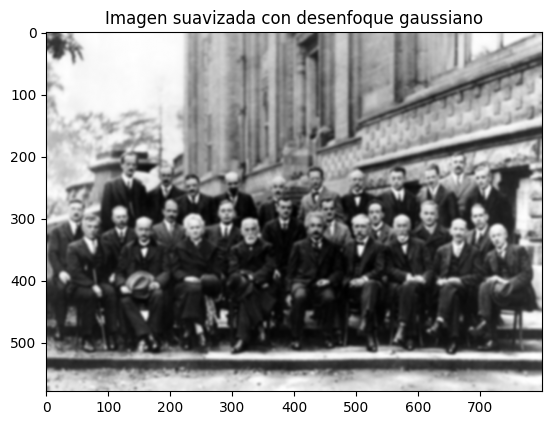

In [12]:
# Suavizado
suavizado = cv2.GaussianBlur(grises, (9, 9), 2)

plt.figure()
plt.imshow(suavizado, cmap="gray")
plt.show()

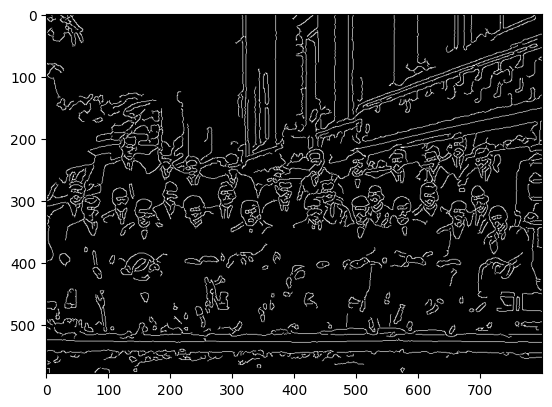

In [15]:
# Bordes Canny
bordes = cv2.Canny(suavizado, 40, 120)

plt.figure()
plt.imshow(bordes, cmap="gray")
plt.show()

Se detectaron 210 posibles objetos circulares.


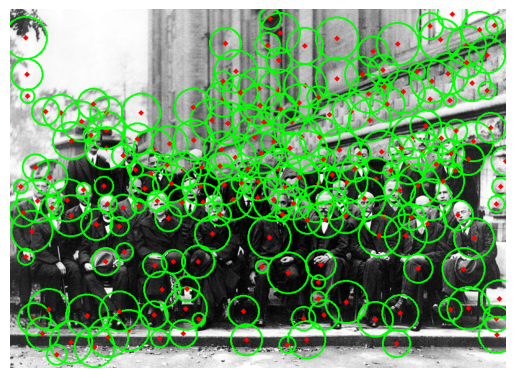

In [19]:
# Detección circulos
circles = cv2.HoughCircles(
    suavizado,
    cv2.HOUGH_GRADIENT,
    dp=1.2,          # Resolución del acumulador
    minDist=25,      # Distancia mínima entre centros detectados
    param1=80,       # Umbral alto usado por Canny internamente
    param2=18,       # Sensibilidad para aceptar círculos
    minRadius=10,    # Radio mínimo esperado
    maxRadius=35     # Radio máximo esperado
)

img_circles = img_rgb.copy()

resultados = []

circles = np.uint16(np.around(circles))

for idx, circle in enumerate(circles[0, :], start=1):
    x, y, r = circle

    # Dibujar círculo
    cv2.circle(img_circles, (x, y), r, (0, 255, 0), 2)

    # Dibujar centro
    cv2.circle(img_circles, (x, y), 2, (255, 0, 0), 3)

    resultados.append({
        "objeto": idx,
        "centro_x": int(x),
        "centro_y": int(y),
        "radio": int(r)
    })

print(f"Se detectaron {len(resultados)} posibles objetos circulares.")

plt.figure()
plt.imshow(img_circles)
plt.axis("off")
plt.show()